# Linear Regression: From Scratch to `scikit-learn`


This notebook is organized into three stages:

1. Explore and understand the dataset.
2. Build Simple Linear Regression from scratch using mathematical equations and implementation hints.
3. Apply the same workflow using `scikit-learn`, then apply the same ideas in an independent practice section.



---

## Learning Objectives

This notebook demonstrates how to:

1. Identify the feature $X$ and target $y$.
2. Translate Linear Regression equations into Python.
3. Implement prediction, cost, gradients, and Gradient Descent.
4. Interpret the intercept and slope.
5. Calculate MAE, MSE, RMSE, and $R^2$ manually.
6. Apply Linear Regression using `scikit-learn`.
7. Compare manual and library-based implementations.
8. Complete a new regression task independently.

# Part 1 — The Problem

We want to predict a student's final score based on the number of hours studied.

- **Input feature $X$:** study hours
- **Target $y$:** final score
- **Task type:** Regression
- **Why regression?** Because the output is a continuous numerical value.

Each row represents one student.

## 1. Import the Required Libraries

In the first part, we will use only:

- `NumPy` for numerical calculations.
- `Pandas` for tabular data.
- `Matplotlib` for visualization.

We will not use `sklearn` until we finish building the algorithm manually.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create a Simple Dataset

In [2]:
data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "final_score": [45, 50, 56, 60, 65, 72, 78, 83, 88, 94]
}

df = pd.DataFrame(data)
display(df)

,study_hours,final_score
0,1,45
1,2,50
2,3,56
3,4,60
4,5,65
5,6,72
6,7,78
7,8,83
8,9,88
9,10,94


## 3. Understand the Dataset

Before building any model, we must understand the data:

- How many rows and columns are there?
- Are there any missing values?
- What is the data type of each column?
- Does the relationship between the two variables appear linear?

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (10, 2)

Data types:


,0
study_hours,int64
final_score,int64



Missing values:


,0
study_hours,0
final_score,0



Summary statistics:


,study_hours,final_score
count,10.00000,10.000000
mean,5.50000,69.100000
std,3.02765,16.582789
min,1.00000,45.000000
25%,3.25000,57.000000
50%,5.50000,68.500000
75%,7.75000,81.750000
max,10.00000,94.000000


## 4. Visualize the Relationship

The plot helps us determine whether the relationship appears linear.

If the points follow an approximately straight-line pattern, Linear Regression may be an appropriate choice.

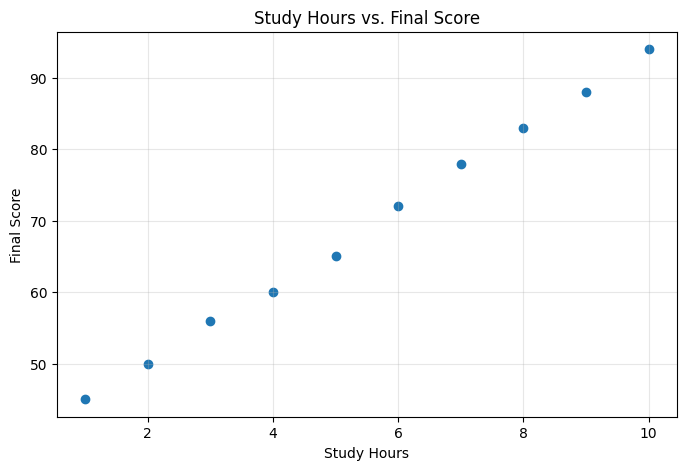

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["final_score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs. Final Score")
plt.grid(alpha=0.3)
plt.show()

# Part 2 — Build Linear Regression From Scratch

In this section, you will translate the mathematical equations discussed in the lecture into Python code.

Each step provides:

- The mathematical equation you need.
- A short implementation hint.
- An incomplete code cell for you to finish.

You may use `NumPy`, `Pandas`, and `Matplotlib`, but you must **not** use `scikit-learn` in this section.

## Step 1 — Prepare the Feature and Target

Create:

- `x`: the input feature containing study hours.
- `y`: the target containing final scores.
- `m`: the number of training examples.

**Hint:** Convert the Pandas columns into NumPy arrays using `.to_numpy(dtype=float)`.

In [5]:

x = df['study_hours'].to_numpy(dtype=float)
y = df['final_score'].to_numpy(dtype=float)
m = len(x)

print("x:", x)
print("y:", y)
print("Number of examples:", m)

x: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y: [45. 50. 56. 60. 65. 72. 78. 83. 88. 94.]
Number of examples: 10


## Step 2 — Initialize the Model Parameters

Start with:


$$
\theta_0 = 0
$$


$$
\theta_1 = 0
$$


Also choose:

- A learning rate $\alpha$
- A number of training iterations

**Hint:** You may start with `learning_rate = 0.01` and `iterations = 2000`.

In [6]:

theta_0 = 0
theta_1 = 0
learning_rate = 0.01
iterations = 2000

print("Initial intercept:", theta_0)
print("Initial slope:", theta_1)

Initial intercept: 0
Initial slope: 0


## Step 3 — Implement the Hypothesis Function

The prediction equation is:


$$
\hat{y} = h_\theta(x) = \theta_0 + \theta_1x
$$


**Hint:** NumPy can apply this equation to the entire `x` array at once.  
Your function should return one prediction for every input value.

In [7]:
def predict(x_values, theta_0, theta_1):
    return theta_0 + theta_1 * x_values

## Step 4 — Calculate the Prediction Error

For each example:


$$
error_i = \hat{y}_i - y_i
$$


**Hint:** First generate predictions using your `predict()` function, then subtract the actual target array.

In [8]:

initial_predictions = predict(x, theta_0, theta_1)
initial_errors = initial_predictions - y

error_table = pd.DataFrame({
    "actual": y,
    "predicted": initial_predictions,
    "error": initial_errors
})

display(error_table)

,actual,predicted,error
0,45.0,0.0,-45.0
1,50.0,0.0,-50.0
2,56.0,0.0,-56.0
3,60.0,0.0,-60.0
4,65.0,0.0,-65.0
5,72.0,0.0,-72.0
6,78.0,0.0,-78.0
7,83.0,0.0,-83.0
8,88.0,0.0,-88.0
9,94.0,0.0,-94.0


## Step 5 — Implement the Cost Function

Use the squared-error cost:


$$
J(\theta_0,\theta_1)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)^2
$$


**Hint:**

1. Generate predictions.
2. Calculate `predictions - y_values`.
3. Square the errors using `** 2`.
4. Sum them using `np.sum()`.
5. Divide by `2 * number_of_examples`.

In [9]:
def compute_cost(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)
    error = predictions - y_values
    cost = error ** 2
    return np.sum(cost) / (2 * len(x_values))

In [10]:

initial_cost = compute_cost(x, y, theta_0, theta_1)
print("Initial cost:", initial_cost)

Initial cost: 2511.15


## Step 6 — Implement the Gradients

Gradient for the intercept:


$$
\frac{\partial J}{\partial \theta_0}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)
$$


Gradient for the slope:


$$
\frac{\partial J}{\partial \theta_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)x_i
$$


**Hint:**

- Calculate the predictions and errors first.
- `np.mean(errors)` gives the intercept gradient.
- Think about what must be multiplied by the errors for the slope gradient.

In [22]:
def compute_gradients(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)

    errors = predictions - y_values

    gradient_0 = np.mean(errors)
    gradient_1 = np.mean(errors * x_values)

    return gradient_0, gradient_1

## Step 7 — Perform One Parameter Update

Update the intercept:


$$
\theta_0
:=
\theta_0
-
\alpha
\frac{\partial J}{\partial \theta_0}
$$


Update the slope:


$$
\theta_1
:=
\theta_1
-
\alpha
\frac{\partial J}{\partial \theta_1}
$$


**Hint:** Calculate both gradients before updating either parameter.

In [23]:
# Use separate demo variables so the main training values are not changed yet.
theta_0_demo = 0.0
theta_1_demo = 0.0

gradient_0, gradient_1 = compute_gradients(x, y, theta_0_demo, theta_1_demo)

theta_0_demo = theta_0_demo - (learning_rate * (gradient_0))
theta_1_demo = theta_1_demo - (learning_rate *(gradient_1))

print("Updated intercept:", theta_0_demo)
print("Updated slope:", theta_1_demo)
print("Cost after one update:", compute_gradients(x, y, theta_0_demo, theta_1_demo))

Updated intercept: 0.691
Updated slope: 4.252
Cost after one update: (np.float64(-45.022999999999996), np.float64(-257.6975))


## Step 8 — Build the Gradient Descent Training Loop

Your function should repeat the following process:

1. Calculate the gradients.
2. Update `theta_0`.
3. Update `theta_1`.
4. Calculate the new cost.
5. Add the cost to `cost_history`.

Return:

- The final intercept.
- The final slope.
- The full cost history.

**Hint:** Use a `for` loop with `range(iterations)`.

In [24]:
def gradient_descent(
    x_values,
    y_values,
    theta_0=0.0,
    theta_1=0.0,
    learning_rate=0.01,
    iterations=2000
):
    cost_history = []

    for iteration in range(iterations):
        gradient_0, gradient_1 = compute_gradients(x_values, y_values, theta_0, theta_1)
        theta_0 = theta_0 - (learning_rate * (gradient_0))
        theta_1 = theta_1 - (learning_rate * (gradient_1))
        cost = compute_cost(x_values, y_values, theta_0, theta_1)
        cost_history.append(cost)

    return theta_0, theta_1, cost_history

## Step 9 — Train the Manual Model

Call your Gradient Descent function using the provided dataset.

**Hint:** Store the returned values in:

- `learned_theta_0`
- `learned_theta_1`
- `cost_history`

In [26]:

learned_theta_0, learned_theta_1, cost_history = gradient_descent(x, y, theta_0_demo, theta_1_demo)

print("Learned intercept:", learned_theta_0)
print("Learned slope:", learned_theta_1)
print("Final cost:", cost_history[-1])

Learned intercept: 38.44193512448187
Learned slope: 5.552888018856137
Final cost: 0.23155368385497538


## Step 10 — Generate Final Predictions

Use the learned equation:


$$
\hat{y}
=
\theta_0
+
\theta_1x
$$


**Hint:** Reuse your `predict()` function with the learned parameter values.

In [27]:

manual_predictions = predict(x, learned_theta_0, learned_theta_1)

print(
    f"Final equation: y_hat = "
    f"{learned_theta_0:.2f} + "
    f"{learned_theta_1:.2f}x"
)

Final equation: y_hat = 38.44 + 5.55x


## Step 11 — Visualize the Training Process

Create two plots:

1. Cost against iteration.
2. Actual data points and the final fitted line.

**Hint:** Use `plt.plot(cost_history)` for the first chart and combine `plt.scatter()` with `plt.plot()` for the second.

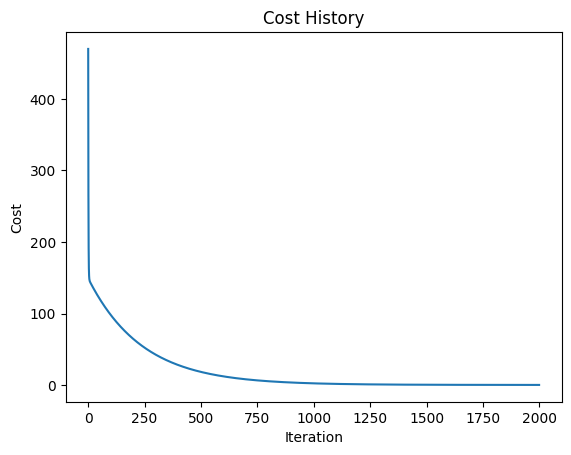

In [29]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost History")
plt.show()

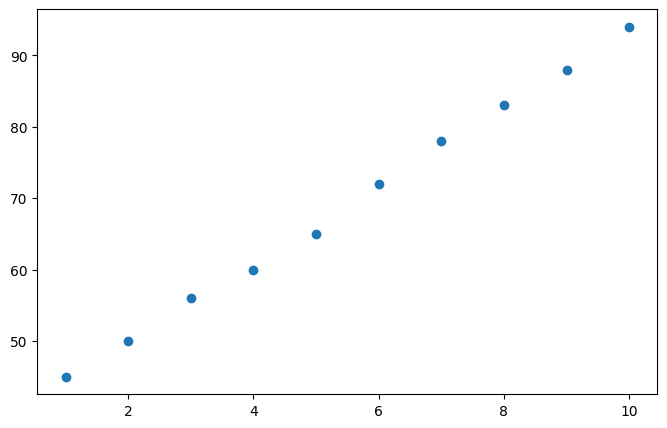

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["final_score"])

## Step 12 — Inspect Predictions and Residuals

Residual:


$$
residual_i = y_i - \hat{y}_i
$$


**Hint:** Build a DataFrame containing the input, actual target, prediction, and residual.

In [32]:

results = pd.DataFrame({
    "study_hours": x,
    "actual_score": y,
    "predicted_score": predict(x, learned_theta_0, learned_theta_1),
    "residual": y - predict(x, learned_theta_0, learned_theta_1)
})

display(results.round(2))

,study_hours,actual_score,predicted_score,residual
0,1.0,45.0,43.99,1.01
1,2.0,50.0,49.55,0.45
2,3.0,56.0,55.10,0.90
3,4.0,60.0,60.65,-0.65
4,5.0,65.0,66.21,-1.21
5,6.0,72.0,71.76,0.24
6,7.0,78.0,77.31,0.69
7,8.0,83.0,82.87,0.13
8,9.0,88.0,88.42,-0.42
9,10.0,94.0,93.97,0.03


## Step 13 — Evaluate the Model Manually

Mean Absolute Error:


$$
MAE
=
\frac{1}{m}
\sum_{i=1}^{m}
|y_i-\hat{y}_i|
$$


Mean Squared Error:


$$
MSE
=
\frac{1}{m}
\sum_{i=1}^{m}
(y_i-\hat{y}_i)^2
$$


Root Mean Squared Error:


$$
RMSE = \sqrt{MSE}
$$


Coefficient of Determination:


$$
R^2
=
1
-
\frac{\sum(y_i-\hat{y}_i)^2}
{\sum(y_i-\bar{y})^2}
$$


**Hint:**

- Use `np.abs()` for MAE.
- Use `np.mean()` for averages.
- Use `np.sqrt()` for RMSE.
- The numerator of $R^2$ is the residual sum of squares.
- The denominator compares the actual values with their mean.

In [36]:
def regression_metrics(y_true, y_pred):

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    sum_squared_residuals = np.sum((y_true - y_pred) ** 2)
    total_sum_of_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sum_squared_residuals / total_sum_of_squares

    return mae, mse, rmse, r2

In [38]:

manual_mae, manual_mse, manual_rmse, manual_r2 = regression_metrics(y, predict(x, learned_theta_0, learned_theta_1))

print("Manual MAE :", manual_mae)
print("Manual MSE :", manual_mse)
print("Manual RMSE:", manual_rmse)
print("Manual R²  :", manual_r2)

Manual MAE : 0.5727387143805899
Manual MSE : 0.46310736770995076
Manual RMSE: 0.6805199245503035
Manual R²  : 0.9981287835156574


## Step 14 — Predict a New Value

Predict the final score for a student who studies for **7.5 hours**.

**Hint:** Pass the new input and the learned parameters to your prediction function.

In [39]:
new_study_hours = 7.5

predicted_score = predict(new_study_hours, learned_theta_0, learned_theta_1)

print(
    f"Predicted score for {new_study_hours} study hours: "
    f"{predicted_score:.2f}"
)

Predicted score for 7.5 study hours: 80.09


## Manual Implementation Checkpoint

Before moving to `scikit-learn`, verify that:

- The cost decreases during training.
- The final line follows the general trend of the data.
- The manual prediction function works for both arrays and single values.
- The evaluation metrics return numeric results.
- The learned intercept and slope are close to the later `scikit-learn` values.

# Part 3 — Apply Linear Regression Using `scikit-learn`

Now we will implement the same model using `sklearn`.

> Important: `LinearRegression` hides the internal mathematical work.  
> It learns the ordinary least-squares solution using numerical linear algebra.  
> The manual implementation above was designed to make the learning process visible.

## 15. Import the Model and Metrics

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("scikit-learn imported successfully.")

scikit-learn imported successfully.


## 16. Prepare $X$ and $y$

`scikit-learn` expects `X` to be a two-dimensional table.

In [41]:
X_sklearn = df[["study_hours"]]
y_sklearn = df["final_score"]

print("X shape:", X_sklearn.shape)
print("y shape:", y_sklearn.shape)

X shape: (10, 1)
y shape: (10,)


## 17. Create and Train the Model

In [42]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_sklearn, y_sklearn)

print("Intercept:", sklearn_model.intercept_)
print("Coefficient:", sklearn_model.coef_[0])

Intercept: 38.999999999999986
Coefficient: 5.472727272727274


## 18. Make Predictions

In [43]:
sklearn_predictions = sklearn_model.predict(X_sklearn)

sklearn_results = df.copy()
sklearn_results["predicted_score"] = sklearn_predictions
sklearn_results["residual"] = (
    sklearn_results["final_score"]
    - sklearn_results["predicted_score"]
)

display(sklearn_results.round(2))

,study_hours,final_score,predicted_score,residual
0,1,45,44.47,0.53
1,2,50,49.95,0.05
2,3,56,55.42,0.58
3,4,60,60.89,-0.89
4,5,65,66.36,-1.36
5,6,72,71.84,0.16
6,7,78,77.31,0.69
7,8,83,82.78,0.22
8,9,88,88.25,-0.25
9,10,94,93.73,0.27


## 19. Evaluate the `sklearn` Model

In [44]:
sklearn_mae = mean_absolute_error(
    y_sklearn,
    sklearn_predictions
)

sklearn_mse = mean_squared_error(
    y_sklearn,
    sklearn_predictions
)

sklearn_rmse = np.sqrt(sklearn_mse)

sklearn_r2 = r2_score(
    y_sklearn,
    sklearn_predictions
)

print("MAE :", sklearn_mae)
print("MSE :", sklearn_mse)
print("RMSE:", sklearn_rmse)
print("R²  :", sklearn_r2)

MAE : 0.501818181818183
MSE : 0.39636363636363575
RMSE: 0.629574170661119
R²  : 0.9983984660537248


## 20. Compare the Manual and `sklearn` Results

The values should be very close.

A small difference may remain because our Gradient Descent stopped after a fixed number of iterations.

In [45]:
comparison_table = pd.DataFrame({
    "Method": ["From Scratch", "scikit-learn"],
    "Intercept": [
        learned_theta_0,
        sklearn_model.intercept_
    ],
    "Slope": [
        learned_theta_1,
        sklearn_model.coef_[0]
    ],
    "MAE": [
        manual_mae,
        sklearn_mae
    ],
    "RMSE": [
        manual_rmse,
        sklearn_rmse
    ],
    "R2": [
        manual_r2,
        sklearn_r2
    ]
})

display(comparison_table.round(4))

,Method,Intercept,Slope,MAE,RMSE,R2
0,From Scratch,38.4419,5.5529,0.5727,0.6805,0.9981
1,scikit-learn,39.0000,5.4727,0.5018,0.6296,0.9984


## 21. Visualize the `sklearn` Model

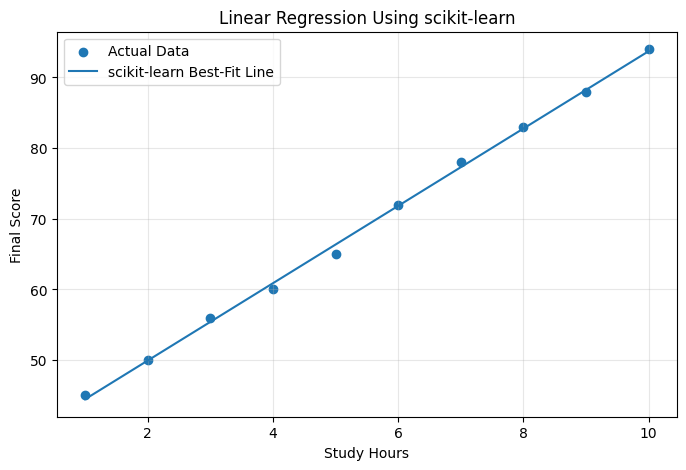

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_sklearn["study_hours"],
    y_sklearn,
    label="Actual Data"
)
plt.plot(
    X_sklearn["study_hours"],
    sklearn_predictions,
    label="scikit-learn Best-Fit Line"
)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Linear Regression Using scikit-learn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 4 — Practical Workflow with Train/Test Split

In real projects, we should not evaluate the final model only on the same data used for training.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sklearn,
    y_sklearn,
    test_size=0.2,
    random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples :", len(X_test))

Training examples: 8
Testing examples : 2


In [48]:
test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)
test_r2 = r2_score(y_test, test_predictions)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²  :", test_r2)

test_results = pd.DataFrame({
    "study_hours": X_test["study_hours"],
    "actual_score": y_test,
    "predicted_score": test_predictions
})

display(test_results.round(2))

Test MAE : 0.2198275862068968
Test RMSE: 0.2528817266184903
Test R²  : 0.9998228554912534


,study_hours,actual_score,predicted_score
8,9,88,88.34
1,2,50,49.91


> **Teaching Note:** This dataset is intentionally small.  
> With only two test examples, the test metrics can change considerably depending on the split.  
> Real projects require more observations and more reliable validation.

# Part 5 — Independent Practice

## Scenario

A training center wants to estimate a student's assessment score based on the number of completed practice sessions.

Each row represents one student.

### Required Work

Complete the task **from the beginning**:

1. Create and inspect the dataset.
2. Define the feature and target.
3. Visualize the relationship.
4. Build Simple Linear Regression manually.
5. Implement the cost function.
6. Implement Gradient Descent.
7. Plot the cost history.
8. Plot the best-fit line.
9. Calculate MAE, MSE, RMSE, and $R^2$ manually.
10. Predict the score for a student who completes 11 sessions.
11. Repeat the model using `scikit-learn`.
12. Compare both implementations.
13. Interpret the intercept, slope, and model performance.

In [49]:
task_data = {
    "practice_sessions": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14],
    "assessment_score": [42, 47, 51, 55, 61, 66, 70, 74, 80, 84, 91, 97]
}

task_df = pd.DataFrame(task_data)
display(task_df)

,practice_sessions,assessment_score
0,1,42
1,2,47
2,3,51
3,4,55
4,5,61
5,6,66
6,7,70
7,8,74
8,9,80
9,10,84


## Task 1 — Understand the Data

Answer:

- What does each row represent?
- How many rows and columns are there?
- Which column is the feature?
- Which column is the target?
- Why is this a regression problem?

In [50]:
# YOUR CODE HERE
# Display shape, data types, missing values, and descriptive statistics.

task_df.shape

(12, 2)

In [52]:
task_df.dtypes

,0
practice_sessions,int64
assessment_score,int64


In [54]:
task_df.isna().sum()

,0
practice_sessions,0
assessment_score,0


In [55]:
task_df.describe()

,practice_sessions,assessment_score
count,12.000000,12.000000
mean,6.750000,68.166667
std,4.025487,17.678098
min,1.000000,42.000000
25%,3.750000,54.000000
50%,6.500000,68.000000
75%,9.250000,81.000000
max,14.000000,97.000000


## Task 2 — Visualize the Relationship

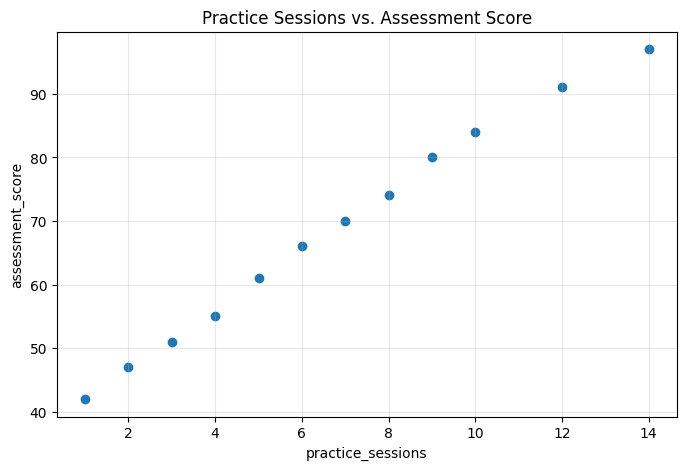

In [56]:
# YOUR CODE HERE
# Create a scatter plot.

plt.figure(figsize=(8, 5))
plt.scatter(task_df["practice_sessions"], task_df["assessment_score"])
plt.xlabel("practice_sessions")
plt.ylabel("assessment_score")
plt.title("Practice Sessions vs. Assessment Score")
plt.grid(alpha=0.3)
plt.show()

## Task 3 — Prepare $x$ and $y$

In [68]:
# YOUR CODE HERE

X = task_df[['practice_sessions']]
Y = task_df['assessment_score']

## Task 4 — Implement the Hypothesis Function

In [58]:
def task_predict(x_values, theta_0, theta_1):
    return theta_0 + theta_1 * x_values

## Task 5 — Implement the Cost Function

In [59]:
def task_compute_cost(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)
    error = predictions - y_values
    cost = error ** 2
    return np.sum(cost) / (2 * len(x_values))

## Task 6 — Implement the Gradients

In [61]:
def task_compute_gradients(x_values, y_values, theta_0, theta_1):
    predictions = predict(x_values, theta_0, theta_1)

    errors = predictions - y_values

    gradient_0 = np.mean(errors)
    gradient_1 = np.mean(errors * x_values)

    return gradient_0, gradient_1

## Task 7 — Implement Gradient Descent

In [62]:
def gradient_descent(
    x_values,
    y_values,
    theta_0=0.0,
    theta_1=0.0,
    learning_rate=0.01,
    iterations=2000
):
    cost_history = []

    for iteration in range(iterations):
        gradient_0, gradient_1 = compute_gradients(x_values, y_values, theta_0, theta_1)
        theta_0 = theta_0 - (learning_rate * (gradient_0))
        theta_1 = theta_1 - (learning_rate * (gradient_1))
        cost = compute_cost(x_values, y_values, theta_0, theta_1)
        cost_history.append(cost)

    return theta_0, theta_1, cost_history

## Task 8 — Train the Manual Model

In [65]:
# # Suggested starting values:
# theta_0 = 0.0
# theta_1 = 0.0
# learning_rate = 0.005
# iterations = 3000

# # YOUR CODE HERE

# learned_theta_0, learned_theta_1, cost_history = gradient_descent(x, y, theta_0, theta_1)

# print("Learned intercept:", learned_theta_0)
# print("Learned slope:", learned_theta_1)
# print("Final cost:", cost_history[-1])

## Task 9 — Plot the Cost and Best-Fit Line

In [ ]:
# YOUR CODE HERE

pass

## Task 10 — Evaluate the Manual Model

In [ ]:
# YOUR CODE HERE
# Calculate MAE, MSE, RMSE, and R² without sklearn.

pass

## Task 11 — Make a New Prediction

Predict the assessment score for **11 practice sessions**.

In [ ]:
# YOUR CODE HERE

pass

## Task 12 — Repeat Using `scikit-learn`

In [74]:
# YOUR CODE HERE
# Create X and y, fit LinearRegression, predict, and evaluate.

x_train, y_train, x_test, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X, Y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 38.610565684899484
Coefficient: 4.378681626928472


In [75]:
sklearn_predictions = model.predict(X)

sklearn_mae = mean_absolute_error(
    Y,
    sklearn_predictions
)

sklearn_mse = mean_squared_error(
    Y,
    sklearn_predictions
)

sklearn_rmse = np.sqrt(sklearn_mse)

sklearn_r2 = r2_score(
    Y,
    sklearn_predictions
)

print("MAE :", sklearn_mae)
print("MSE :", sklearn_mse)
print("RMSE:", sklearn_rmse)
print("R²  :", sklearn_r2)

MAE : 1.04932211313698
MSE : 1.67547140408291
RMSE: 1.294400017028318
R²  : 0.9941513652141002


## Task 13 — Interpretation Questions

Write your answers:

1. What does the slope mean in this dataset?
2. Is the intercept practically meaningful? Explain.
3. Did the cost decrease during training?
4. Were the manual and `sklearn` results close?
5. What does the RMSE tell us?
6. What does the $R^2$ score tell us?
7. Can this analysis prove that practice sessions cause higher scores?
8. What other features could improve the model?

In [ ]:
# 1.

# 2.

# 3.

# 4.

# 5.

# 6.

# 7.

# 8.